# **Network Packet Security Analysis Chatbot using SQL RAG and Knowledge Graph RAG Approach using Cybersecurity-Tuned LLM**

# **Overview**
This project provides an advanced framework for cybersecurity security analysis through a conversational interface. It empowers security analysts to investigate network traffic data by asking questions in natural language.

The core of this system is segolilylabs/Lily-Cybersecurity-7B-v0.2, a Large Language Model (LLM) specifically fine-tuned for the cybersecurity domain. This specialization allows it to understand the nuances of network protocols, attack patterns, and security-specific terminology, leading to more accurate and relevant analysis.

The framework's main feature is a dual-analysis engine that enables analysts to investigate data using two complementary methods: a Text-to-SQL approach for database-wide queries and a RAG-like approach for deep, context-specific analysis.

# **Cybersecurity-Centric Architecture**
The project's architecture is designed to support a typical security analysis workflow, from raw data ingestion to actionable insights. The workflow  explicitly evaluate the two distinct analysis modes derived from from `bizbot.py`: **SQL Data Query** and **AI Security Analysis (RAG)** used in an attack sample of network traffic capture. The final output is a clear Ragas score for each mode, allowing for a direct performance comparison.

**Key Components:**
*   pcap2csv-ok.py: A utility that parses raw packet captures (.pcap) and extracts a curated set of security-relevant features into a CSV file, creating a structured dataset ready for investigation.
*   Segolily LLM (The AI Analyst): The core of the system. As a cybersecurity-tuned LLM, it excels at: Generating precise SQL queries for threat hunting in network logs, Understanding security context to analyze specific events (e.g., a single anomalous connection), Recognizing security-related entities like IP addresses, port numbers, and attack types.
*   SQL Data Query Chatbot Application (bizbot.py): The primary interface for the security analyst. Built with Streamlit, it manages data loading and provides access to the dual-analysis engine.

### **Colab Notebook: Evaluating SQL Data Query and RAG Analysis Modes**

---

# **Part 0: Introduction and Setup**

# #### **Cell 1: Introduction**

# Colab Notebook: Comparing Segolily vs. DeepSeek for Cybersecurity Analysis

This notebook provides a framework to rigorously evaluate and compare the performance of two Large Language Models on cybersecurity data analysis tasks:

1.  **Segolily (`segolilylabs/Lily-Cybersecurity-7B-v0.2`)**: A specialized cybersecurity model run locally from Hugging Face.
2.  **DeepSeek R1 (`deepseek/deepseek-r1:7b`)**: A powerful, general-purpose 'reasoning' model accessed via the OpenRouter API.

We will evaluate them on two key modes:
* **SQL Data Query Mode**: Their ability to convert natural language into executable SQL queries.
* **AI Contextual Analysis (RAG) Mode**: Their ability to accurately answer questions based on a provided text context.

The final output is a side-by-side comparison of their `ragas` scores, showing which model is more accurate and faithful for each task.

**Runtime Requirement**: A GPU is required. In Colab, go to `Runtime > Change runtime time` and select **T4 GPU** or better (L4 is recommended).

# #### **Cell 2: Install Dependencies**

In [ ]:
# Install all required libraries
!pip install -q pandas pandasql
!pip install -q transformers accelerate
!pip install -q datasets langchain ragas
!pip install -q langchain-openai # Install the OpenAI integration for Langchain/Ragas
!pip install -q openai

In [ ]:
# Load secrets configured in Colab's sidebar
from google.colab import userdata
import os

# Assuming your OpenRouter API key secret is named 'OPENROUTER_API_KEY' in the Colab Secrets sidebar
# Replace 'OPENROUTER_API_KEY' if you used a different name for your secret
try:
    openrouter_api_key = userdata.get('OpenrouterAPI_rageval_obrina')
    # Set the environment variable that langchain/ragas expects
    os.environ["OPENAI_API_KEY"] = openrouter_api_key
    print("OpenRouter API key loaded from Colab Secrets and set as OPENAI_API_KEY environment variable.")
except userdata.SecretNotFoundError:
    print("Error: 'OPENROUTER_API_KEY' not found in Colab Secrets.")
    print("Please add your OpenRouter API key to the Colab Secrets sidebar with the name 'OPENROUTER_API_KEY'.")
    # You might want to stop execution here if the key is not found
    # raise ValueError("'OPENROUTER_API_KEY' secret not found.")

# Set the base URL for OpenRouter (it's an OpenAI-compatible endpoint)
# This can be hardcoded as it's not a sensitive secret
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"
print("OpenRouter API base URL environment variable set.")

# You can optionally verify the environment variables are set (without printing the key value)
# print(f"OPENAI_API_KEY is set: {'OPENAI_API_KEY' in os.environ}")
# print(f"OPENAI_API_BASE is set: {'OPENAI_API_BASE' in os.environ}")

OpenRouter API key loaded from Colab Secrets and set as OPENAI_API_KEY environment variable.
OpenRouter API base URL environment variable set.


In [ ]:
from openai import OpenAI

# Create client (will use environment variables automatically)
openrouter_client = OpenAI()

# Test the connection
try:
    response = openrouter_client.chat.completions.create(
        model="mistralai/mistral-7b-instruct",
        messages=[{"role": "user", "content": "Hi"}]
    )
    print("✅ OpenRouter client configured and tested successfully.")
    print(f"Response: {response.choices[0].message.content}")

except Exception as e:
    print(f"❌ Error: {e}")

# Define the model name for easier use later
model_name_mistral = "mistralai/mistral-7b-instruct"
model_name_deepseek = "deepseek/deepseek-r1-distill-qwen-7b"

✅ OpenRouter client configured and tested successfully.
Response:  Hello! How can I assist you today? If you have a specific question or topic you'd like to discuss, feel free to ask. I'm here to help with a wide range of subjects.


---

### **Part 1: Model and Data Preparation**

#### **Cell 3: Load Segolily/Cybersecurity LLM and Tokenizer Locally**

Segolily is a cybersecurity assistant. She is a Mistral Fine-tune model with 22,000 hand-crafted cybersecurity and hacking-related data pairs. This dataset was then run through a LLM to provide additional context, personality, and styling to the outputs.

The dataset focuses on general knowledge in most areas of cybersecurity. Segolily documentation can be found on https://huggingface.co/segolilylabs/Lily-Cybersecurity-7B-v0.2

In [ ]:
# Ensure the latest version of bitsandbytes is installed just before use
!pip install -U -q bitsandbytes

# Add a simple check to confirm bitsandbytes is available
try:
    import bitsandbytes as bnb
    print("bitsandbytes installed successfully.")
except ImportError:
    # If this still fails, there's a deeper environment issue or conflict
    print("Error: bitsandbytes not found after installation.")
    # You might consider restarting the runtime if this happens
    # get_ipython().kernel.do_shutdown(True) # Uncomment to force restart

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# Load the locally-run Segolily model with 4-bit quantization
model_name_segolily = "segolilylabs/Lily-Cybersecurity-7B-v0.2"

# Define the configuration for 4-bit loading
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading local model: Segolily... (This will take a few minutes)")

try:
    # Load the tokenizer and model with the specified quantization config
    tokenizer_segolily = AutoTokenizer.from_pretrained(model_name_segolily)
    model_segolily = AutoModelForCausalLM.from_pretrained(
        model_name_segolily,
        quantization_config=quantization_config,
        torch_dtype=torch.float16,
        device_map="auto", # This will automatically use the GPU
    )

    # Create a transformers pipeline for easier text generation
    hf_pipeline_segolily = pipeline(
        "text-generation",
        model=model_segolily,
        tokenizer=tokenizer_segolily,
        max_new_tokens=200, # Increased token limit for potentially longer SQL queries
        temperature=0.01,   # Keep low for deterministic, factual outputs
    )
    print("✅ Segolily model loaded successfully.")

except Exception as e:
    print(f"❌ An error occurred during model loading: {e}")
    print("Please ensure you have a GPU runtime enabled (Runtime -> Change runtime type -> T4 GPU or L4).")
    print("If using a GPU, consider restarting the Colab runtime (Runtime -> Restart runtime) and trying again.")

bitsandbytes installed successfully.
Loading local model: Segolily... (This will take a few minutes)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Device set to use cuda:0


✅ Segolily model loaded successfully.


#### **Cell 4: Load and Prepare the Edge-IIoT Dataset**
Edge-IIoTset is a comprehensive realistic cyber security dataset of IoT and IIoT applications, which can be used by AI-based intrusion detection systems in both centralized and federated learning. Edge-IIoTset are generated from various IoT devices (more than 10 types) such as Low-cost digital sensors for sensing temperature and humidity, Ultrasonic sensor, Water level detection sensor, pH Sensor Meter, Soil Moisture sensor, Heart Rate Sensor, Flame Sensor, …etc. Furthermore, the dataset represent 14 attacks related to IoT and IIoT connectivity protocols, which are categorized into five threats: DoS/DDoS attacks, Information gathering, MiTM attacks, Injection attacks, and Malware attacks. Edge-IIoTset has been published in the paper https://doi.org/10.1109/ACCESS.2022.3165809 and the dataset can be found in https://www.kaggle.com/code/waleedgul/predict-attack-and-attack-type/input

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
from pandasql import sqldf

# Define the path to your CSV file in Google Drive
# IMPORTANT: Replace 'Your_Folder_Name' with the actual path to your folder in Drive
# Example: If the file is in a folder named 'iot_data' directly in your Drive's root,
# the path might be '/content/drive/MyDrive/iot_data/ML-EdgeIIoT-dataset.csv'
# If it's in 'My Drive/Colab Notebooks/data/ML-EdgeIIoT-dataset.csv', the path is
# '/content/drive/MyDrive/Colab Notebooks/data/ML-EdgeIIoT-dataset.csv'

# !!! REPLACE THIS WITH YOUR ACTUAL FILE PATH IN GOOGLE DRIVE !!!
LABELED_CSV_FILE = '/content/drive/MyDrive/PHDS/experiment/bizbot-segolily/toniot-dataset/sampled_toniot_dataset.csv'

print(f"Attempting to load dataset from Google Drive: {LABELED_CSV_FILE}")

# Check if the file exists before trying to load
if not os.path.exists(LABELED_CSV_FILE):
    print(f"Error: File not found at '{LABELED_CSV_FILE}'")
    print("Please double-check the path in Google Drive.")
    print("Make sure Google Drive is mounted and the path copied from the Colab file explorer is correct.")
    # You might want to stop execution here if the file isn't found
    # raise FileNotFoundError(f"Dataset not found at {LABELED_CSV_FILE}")
else:
    print("File found. Loading into pandas DataFrame...")
    # Load the data into a pandas DataFrame
    # Use appropriate encoding if necessary (e.g., encoding='latin1')
    try:
        # It's common for IoT datasets to have encoding issues, try 'latin1' or others if utf-8 fails
        try:
            df = pd.read_csv(LABELED_CSV_FILE)
        except UnicodeDecodeError:
            print("UTF-8 decode failed, trying latin1 encoding...")
            df = pd.read_csv(LABELED_CSV_FILE, encoding='latin1')
        except Exception as e:
            print(f"An unexpected error occurred while reading the CSV: {e}")
            # Re-raise the exception if it's not a decoding issue we handled
            raise e


    except FileNotFoundError:
         print(f"Error: File not found at '{LABELED_CSV_FILE}'. Please ensure the path is correct.")
         # Handle or re-raise the error as appropriate
         # raise
    except Exception as e:
        print(f"An error occurred while loading the CSV file: {e}")
        print("Please check the file format and content.")
        # Handle or re-raise the error as appropriate
        # raise


    # IMPORTANT: Clean column names to be SQL-friendly (replace dots and spaces/special chars)
    # Also handle potential leading/trailing whitespace in column names
    df.columns = df.columns.str.strip().str.replace('[^a-zA-Z0-9_]', '_', regex=True)

    # This function allows us to query the pandas DataFrame using SQL syntax
    pysqldf = lambda q: sqldf(q, globals())

    print("Data loaded. Columns are now SQL-friendly.")
    print("\n--- DataFrame Head ---")
    display(df.head()) # Use display instead of print for better formatting in Colab

    # Optional: Print info about the dataframe to verify
    print("\n--- DataFrame Info ---")
    df.info()

Attempting to load dataset from Google Drive: /content/drive/MyDrive/PHDS/experiment/bizbot-segolily/toniot-dataset/sampled_toniot_dataset.csv
File found. Loading into pandas DataFrame...
Data loaded. Columns are now SQL-friendly.

--- DataFrame Head ---


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,dst_ip_bytes,dns_query,dns_rejected,ssl_version,ssl_cipher,http_method,http_uri,http_version,label,type
0,192.168.1.193,49739,192.168.1.33,80,tcp,-,0.000018,0,0,REJ,...,40,-,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49401,192.168.1.37,8080,tcp,-,0.000138,0,0,REJ,...,40,-,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49663,192.168.1.33,80,tcp,-,0.000022,0,0,REJ,...,40,-,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49345,192.168.1.37,8080,tcp,-,0.000009,0,0,REJ,...,40,-,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49875,192.168.1.37,8080,tcp,-,0.000142,0,0,REJ,...,40,-,-,-,-,-,-,-,1,backdoor



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   src_ip        1000 non-null   object 
 1   src_port      1000 non-null   int64  
 2   dst_ip        1000 non-null   object 
 3   dst_port      1000 non-null   int64  
 4   proto         1000 non-null   object 
 5   service       1000 non-null   object 
 6   duration      1000 non-null   float64
 7   src_bytes     1000 non-null   int64  
 8   dst_bytes     1000 non-null   int64  
 9   conn_state    1000 non-null   object 
 10  missed_bytes  1000 non-null   int64  
 11  src_pkts      1000 non-null   int64  
 12  src_ip_bytes  1000 non-null   int64  
 13  dst_pkts      1000 non-null   int64  
 14  dst_ip_bytes  1000 non-null   int64  
 15  dns_query     1000 non-null   object 
 16  dns_rejected  1000 non-null   object 
 17  ssl_version   1000 non-null   object 
 18  ssl_c

---

### **Part 2: Generate Evaluation Dataset**

#### **Cell 5: Dynamically Generate 20 Question/Answer Ground Truths**
To evaluate an LLM-based analysis solution, we require a grounded truth, which is a set of data which act as an anchor of truth and correctness. This ground truth data will be use as the evaluation baseline which will be compared against the answer provided by the LLM.

In [ ]:
from datasets import Dataset
import json
from tqdm.notebook import tqdm

def generate_evaluation_dataset(client, dataframe, num_questions=20):
    """Generates a question-answer evaluation dataset using an LLM."""
    if not client:
        print("API client is not available. Skipping generation.")
        return None

    schema = dataframe.columns.to_list()
    data_sample = dataframe.sample(n=5, random_state=42).to_string()

    print(f"Generating {num_questions} Question/SQL pairs using {model_name_deepseek}...")
    prompt = f"""
    You are an expert cybersecurity data analyst. Your task is to generate {num_questions} complex and diverse questions that a security analyst would ask about a network traffic dataset.
    For each question, you MUST also provide a syntactically correct SQL query that answers it based on the provided schema.

    **Database Schema:**
    Table Name: df
    Columns: {', '.join(schema)}

    **Sample Data Rows:**
    {data_sample}

    **Instructions:**
    - Create a mix of questions: simple counts, groupings (GROUP BY), filtering (WHERE), uniqueness (DISTINCT), and ordering (ORDER BY).
    - Ensure the questions are relevant to cybersecurity analysis (e.g., query for attack types, suspicious IPs, port scans).
    - The SQL queries must be runnable against a table named 'df' using SQLite syntax.
    - Respond ONLY with a valid JSON array of objects, where each object has a "question" and a "sql_query" key.
    - ABSOLUTELY DO NOT include any introductory text, explanations, or comments outside of the JSON array.
    - If you cannot generate a valid query for a question, omit that question/query pair from the JSON.

    **JSON Output Format:**
    [
      {{"question": "Your generated question here...", "sql_query": "SELECT ... FROM df WHERE ..."}},
      ...
    ]
    """
    try:
        response = client.chat.completions.create(
            model=model_name_deepseek,
            messages=[{"role": "user", "content": prompt}],
        )
        qa_sql_pairs = json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"An error occurred during API call or JSON parsing: {e}")
        return None

    print(f"✅ Generated {len(qa_sql_pairs)} pairs. Now executing SQL to create ground truths...")
    ground_truth_data = []
    for item in tqdm(qa_sql_pairs, desc="Processing Queries"):
        try:
            result_df = pysqldf(item["sql_query"])
            ground_truth_answer = f"The query returned the following result: {result_df.to_string(index=False)}"
            item["ground_truth"] = ground_truth_answer
            ground_truth_data.append(item)
        except Exception:
            continue # Skip invalid SQL queries

    print(f"✅ Created {len(ground_truth_data)} ground truth question-answer pairs.")
    return ground_truth_data

# Generate the master list of questions and ground truths
ground_truth_dataset = generate_evaluation_dataset(openrouter_client, df, num_questions=20)

Generating 20 Question/SQL pairs using deepseek/deepseek-r1-distill-qwen-7b...
✅ Generated 20 pairs. Now executing SQL to create ground truths...


Processing Queries:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Created 14 ground truth question-answer pairs.


In [ ]:
if ground_truth_dataset:
    print("\n\n--- Generated Question/SQL Pairs for Evaluation ---")
    # Convert to a pandas DataFrame for prettier printing
    display_df = pd.DataFrame(ground_truth_dataset)
    for index, row in display_df.iterrows():
        print(f"#{index + 1}:")
        print(f"  Question: {row['question']}")
        print(f"  SQL Query: {row['sql_query']}\n")



--- Generated Question/SQL Pairs for Evaluation ---
#1:
  Question: Which attack types are most common?
  SQL Query: SELECT type FROM df GROUP BY type ORDER BY COUNT(type) DESC

#2:
  Question: What are the top 10 source IPs with the most traffic?
  SQL Query: SELECT src_ip, COUNT(*) FROM df GROUP BY src_ip ORDER BY COUNT(*) DESC LIMIT 10

#3:
  Question: Which destinations have the most traffic?
  SQL Query: SELECT dst_ip, COUNT(*) FROM df GROUP BY dst_ip ORDER BY COUNT(*) DESC

#4:
  Question: What are the most common protocols used?
  SQL Query: SELECT proto FROM df GROUP BY proto ORDER BY COUNT(proto) DESC

#5:
  Question: Which services are most used?
  SQL Query: SELECT service FROM df GROUP BY service ORDER BY COUNT(service) DESC LIMIT 10

#6:
  Question: What are the most common connection states?
  SQL Query: SELECT conn_state FROM df GROUP BY conn_state ORDER BY COUNT(conn_state) DESC

#7:
  Question: Which services are malicious?
  SQL Query: SELECT service FROM df WHERE s

---

### **Part 3: Run and Evaluate Both Models**

#### **Cell 6: Define Answer Generation Functions**
These functions prepare for the evaluation by defining how to get answers from the LLMs in two ways:
generate_sql_from_question creates a database query

*   from a question and schema for the SQL mode, which get_sql_answer then runs to get the actual data result;
*   get_rag_answer provides a relevant data context to the LLM along with a question, prompting it to generate a natural language answer based solely on that information for the RAG mode.

In [ ]:
import re

# --- Functions for SQL Mode ---
def generate_sql_from_question(question, schema, pipeline, model_name, client=None):
    prompt = f"You are a Text-to-SQL model. Generate a single SQL query based on the user's question and the database schema. Output only the SQL query. The table name is 'df'.\n\n**Schema:** {', '.join(schema)}\n\n**Question:** {question}\n\n**SQL Query:**"
    if client: # API-based model
        response = client.chat.completions.create(model=model_name, messages=[{"role": "user", "content": prompt}])
        sql_query = response.choices[0].message.content
    else: # Local pipeline
        response = pipeline(prompt)[0]['generated_text']
        sql_query = response.split("SQL Query:")[1].strip()
    return re.sub(r';.*', '', sql_query).strip() # Clean up query

def get_sql_answer(sql_query):
    try:
        result_df = pysqldf(sql_query)
        return f"The query returned the following result: {result_df.to_string(index=False)}"
    except Exception as e:
        return f"An error occurred: {str(e)}"

# --- Functions for RAG Mode ---
def get_rag_answer(question, context, pipeline, model_name, client=None):
    prompt = f"You are a precise cybersecurity analyst AI. Answer the question based ONLY on the data context provided.\n\n**Data Context:**\n{context}\n\n**Question:**\n{question}\n\n**Answer:**"
    if client: # API-based model
        response = client.chat.completions.create(model=model_name, messages=[{"role": "user", "content": prompt}])
        answer = response.choices[0].message.content
    else: # Local pipeline
        response = pipeline(prompt)[0]['generated_text']
        answer = response.split("Answer:")[1].strip()
    return answer

print("✅ Answer generation functions defined.")

✅ Answer generation functions defined.


#### **Cell 7: Generate All Answers from Both Models**
This code block is a crucial step in the evaluation process. It takes the questions generated in the previous step and uses the two different language models, Segolily and DeepSeek, to produce answers based on the defined "SQL Data Query" and "RAG Contextual Analysis" modes.

In [ ]:
if ground_truth_dataset:
    segolily_sql_results = []
    deepseek_sql_results = []
    segolily_rag_results = []
    deepseek_rag_results = []

    # --- SQL Mode Answer Generation ---
    print("Generating answers for SQL mode...")
    for item in tqdm(ground_truth_dataset, desc="SQL Mode Evaluation"):
        # Segolily
        sql_segolily = generate_sql_from_question(item["question"], df.columns.tolist(), hf_pipeline_segolily, model_name_segolily)
        answer_segolily = get_sql_answer(sql_segolily)
        segolily_sql_results.append({
            "question": item["question"],
            "answer": str(answer_segolily), # Ensure answer is string
            "ground_truth": str(item["ground_truth"]), # Ensure ground_truth is string
            "contexts": [str(f"Generated SQL: {sql_segolily}")] # Ensure context elements are strings
        })

        # DeepSeek
        sql_deepseek = generate_sql_from_question(item["question"], df.columns.tolist(), None, model_name_deepseek, openrouter_client)
        answer_deepseek = get_sql_answer(sql_deepseek)
        deepseek_sql_results.append({
            "question": item["question"],
            "answer": str(answer_deepseek), # Ensure answer is string
            "ground_truth": str(item["ground_truth"]), # Ensure ground_truth is string
            "contexts": [str(f"Generated SQL: {sql_deepseek}")] # Ensure context elements are strings
        })

    # --- RAG Mode Answer Generation ---
    print("\nGenerating answers for RAG mode...")
    # Use the same RAG evaluation dataset as before
    # rag_eval_data is not defined in this block, so we'll regenerate it or assume it's globally available
    # based on the context provided in the original notebook structure.
    # If rag_eval_data is not defined, you'll need to run the cell that creates it (Cell 9 in the original notebook).
    # For this code block, let's assume rag_eval_data is available from previous cell execution.

    # If you are running this cell independently, you might need to add:
    # attack_df = df[df['Attack_label'] != 'Benign'].sample(n=10, random_state=42) # Assuming df is loaded

    rag_eval_list = [] # Use a list here to build the dataset step-by-step

    # Iterate through the data you want to use for RAG evaluation
    # Assuming rag_eval_data is your DataFrame for RAG evaluation
    if 'rag_eval_data' not in locals():
         print("Note: rag_eval_data not found. Assuming the DataFrame for RAG evaluation is created in a separate cell.")
         # If you must define it here, uncomment the next line (but better to do it in its dedicated cell)
         # rag_eval_data = df[df['Attack_label'] != 'Benign'].sample(n=10, random_state=42)


    # Ensure rag_eval_data DataFrame exists and has rows
    if 'rag_eval_data' in locals() and not rag_eval_data.empty:
        for _, row in tqdm(rag_eval_data.iterrows(), desc="RAG Mode Answer Generation", total=len(rag_eval_data)):
            context = row.to_string()
            question = "Based on this data, what is the attack label?"
            # Ensure ground_truth is always a string
            ground_truth = str(row['label'])

            # Segolily
            answer_segolily = get_rag_answer(question, context, hf_pipeline_segolily, model_name_segolily)
            rag_eval_list.append({
                "question": question,
                "answer": str(answer_segolily),  # Ensure answer is string
                "ground_truth": str(ground_truth), # Ensure ground_truth is string
                "contexts": [str(context)]       # Ensure context elements are strings
            })

            # DeepSeek - Note: DeepSeek RAG evaluation happens *after* answer generation
            # The RAG evaluation dataset construction needs to be adjusted
            # We need to generate the dataset structrure first and then run Ragas evaluation separately

        # Let's restructure this section slightly to build the RAG datasets correctly for Ragas
        # The RAG evaluation dataset will be built in Cell 9, and the evaluation run in Cell 10
        # So, let's remove the RAG answer generation from this cell and keep only SQL here.
        # We will generate DeepSeek RAG answers later in Cell 9 when building the dataset.

        # Keeping this part for now to be consistent with the user's original structure,
        # but highlighting it's better done in the dataset preparation cell.
        # If you prefer to keep answer generation here, ensure rag_eval_data is defined
        # and the data structure matches what Ragas expects later.
        pass # Placeholder if keeping this structure


    # Convert results to Hugging Face Datasets
    segolily_sql_dataset = Dataset.from_list(segolily_sql_results)
    deepseek_sql_dataset = Dataset.from_list(deepseek_sql_results)
    # RAG datasets will be created in Cell 9

    print("\n✅ SQL answers generated for both models. RAG dataset preparation will be in Cell 9.")
else:
    print("❌ Ground truth dataset not found (from Cell 5). Cannot proceed with SQL evaluation.")

Generating answers for SQL mode...


SQL Mode Evaluation:   0%|          | 0/14 [00:00<?, ?it/s]


Generating answers for RAG mode...


RAG Mode Answer Generation:   0%|          | 0/20 [00:00<?, ?it/s]


✅ SQL answers generated for both models. RAG dataset preparation will be in Cell 9.


#### **Cell 8: Preparing RAG Contextual Analysis - Evaluation  Dataset**
This code block focuses on preparing the data specifically for evaluating the "RAG Contextual Analysis" mode of the models. RAG stands for Retrieval Augmented Generation. In this mode, the models are given a specific piece of data (the "context") and asked to answer a question based only on that information..

In [ ]:
import pandas as pd
from datasets import Dataset
from tqdm.notebook import tqdm # Import tqdm for the progress bar

# --- Prepare RAG Evaluation Dataset ---
print("Preparing RAG evaluation dataset...")

# Create the DataFrame for RAG evaluation.
# This is assumed to be part of the original "Cell 9" logic.
# We'll sample non-benign attacks for RAG evaluation as per the original plan.
if 'df' in locals() and not df.empty:
    # Filter out benign traffic and sample a smaller DataFrame for RAG evaluation
    # Adjust the number of samples (n=10) as needed for your evaluation
    # IMPORTANT: Replace 'Attack_label' with the actual cleaned column name for the attack label
    # (Check the output of df.columns.tolist() after loading and cleaning the data)
    attack_column_name = 'label' # <--- Corrected column name based on DataFrame columns

    if attack_column_name not in df.columns:
        print(f"Error: Attack label column '{attack_column_name}' not found in DataFrame columns: {df.columns.tolist()}")
        rag_eval_data = pd.DataFrame() # Create an empty DataFrame to prevent further errors
    else:
        # Filter out rows where the attack_column_name is 'Benign'
        rag_eval_data = df[df[attack_column_name] != 'Benign']
        # Sample if the filtered data is still too large or you only need a sample
        if len(rag_eval_data) > 20: # Sample only if there are more than 20 attack samples
             rag_eval_data = rag_eval_data.sample(n=20, random_state=42)
        print(f"Created rag_eval_data DataFrame with {len(rag_eval_data)} samples.")

else:
    print("Error: DataFrame 'df' not found or is empty. Cannot create RAG evaluation dataset.")
    # You should stop execution here if 'df' is not available
    # raise ValueError("DataFrame 'df' not found or is empty.")
    rag_eval_data = pd.DataFrame() # Create an empty DataFrame to avoid errors if df is missing


# Convert the DataFrame into a list of dictionaries, which is the expected format for Dataset.from_list
# Also, generate the Segolily RAG answers here as part of dataset preparation,
# and structure the data for Ragas evaluation later.

if not rag_eval_data.empty:
    rag_dataset_list = []
    print("Generating Segolily RAG answers and building RAG dataset structure...")
    for _, row in tqdm(rag_eval_data.iterrows(), desc="Building RAG Dataset"):
        context = row.to_string()
        question = "Based on this data, what is the attack label?"
        # Use the correct column name here as well
        # FIX: Changed 'Attack_label' to 'label'
        ground_truth = str(row['label'])

        # Generate Segolily RAG answer
        # Ensure hf_pipeline_segolily and model_name_segolily are defined from previous cells
        if 'hf_pipeline_segolily' in locals() and 'model_name_segolily' in locals():
             answer_segolily = get_rag_answer(question, context, hf_pipeline_segolily, model_name_segolily)
        else:
             print("Warning: Segolily pipeline not found. Skipping Segolily RAG answer generation.")
             answer_segolily = "Segolily model not loaded."

        rag_dataset_list.append({
            "question": question,
            "context": str(context), # Store the context
            "answer_segolily": str(answer_segolily), # Store Segolily's answer
            # DeepSeek answer will be generated later, or you can generate it here too
            "ground_truth": str(ground_truth)
        })

    # Now, convert this list to a Hugging Face Dataset
    rag_eval_dataset = Dataset.from_list(rag_dataset_list)
    print(f"✅ Created RAG evaluation dataset with {len(rag_eval_dataset)} entries.")

else:
    print("RAG evaluation dataset not created because rag_eval_data is empty.")
    rag_eval_dataset = Dataset.from_list([]) # Create an empty dataset to avoid errors

Preparing RAG evaluation dataset...
Created rag_eval_data DataFrame with 20 samples.
Generating Segolily RAG answers and building RAG dataset structure...


Building RAG Dataset: 0it [00:00, ?it/s]

✅ Created RAG evaluation dataset with 20 entries.


In [ ]:
print("\nSample RAG evaluation dataset items before Ragas evaluation:")
for i in range(min(5, len(rag_eval_dataset))):
    print(rag_eval_dataset[i])
    print("-" * 30)


Sample RAG evaluation dataset items before Ragas evaluation:
{'question': 'Based on this data, what is the attack label?', 'context': 'src_ip          2405:6e00:10ce:2c00:20c:29ff:feee:e07a\nsrc_port                                         50269\ndst_ip                              2001:503:c27::2:30\ndst_port                                            53\nproto                                              udp\nservice                                            dns\nduration                                           0.0\nsrc_bytes                                            0\ndst_bytes                                            0\nconn_state                                          S0\nmissed_bytes                                         0\nsrc_pkts                                             1\nsrc_ip_bytes                                        88\ndst_pkts                                             0\ndst_ip_bytes                                         0\ndns_query               

#### **Cell 9: Run Ragas Evaluation and Display Comparison**
This code block performs the core evaluation of the two language models, Segolily and DeepSeek, using the ragas library. Ragas is a framework for evaluating Retrieval Augmented Generation (RAG) systems, but it can also be used to assess aspects of model performance like answer correctness.

In [ ]:
!pip install -q langchain-google-genai

from ragas import evaluate
# Import all desired metrics individually
#from ragas.metrics import answer_correctness, faithfulness, context_precision, answer_relevancy
from ragas.metrics import answer_correctness
from ragas.metrics import faithfulness, context_precision, answer_relevancy
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from google.colab import userdata # Import userdata
import os # Import os
import pandas as pd # Import pandas
from tqdm.notebook import tqdm # Ensure tqdm is imported for progress bars
from datasets import Dataset # Import Dataset

# Assuming your Google API key secret is named 'GOOGLE_API_KEY' in the Colab Secrets sidebar
# Replace 'GOOGLE_API_KEY' if you used a different name for your secret
google_api_key = None
try:
    google_api_key = userdata.get('GOOGLE_API_KEY')
    # Set the environment variable that langchain/ragas expects
    os.environ["GOOGLE_API_KEY"] = google_api_key
    print("Google API key loaded from Colab Secrets and set as GOOGLE_API_KEY environment variable.")
except userdata.SecretNotFoundError:
    print("Error: 'GOOGLE_API_KEY' not found in Colab Secrets.")
    print("Please add your Google API key to the Colab Secrets sidebar with the name 'GOOGLE_API_KEY'.")
    # You might want to stop execution here if the key is not found
    # raise ValueError("'GOOGLE_API_KEY' secret not found.")

# Temporarily print masked key for verification (REMOVE THIS LINE LATER!)
# Be careful not to print the whole key!
if google_api_key:
    print(f"Verification: GOOGLE_API_KEY starts with {google_api_key[:5]}..., length {len(google_api_key)}")
else:
     print("Verification: GOOGLE_API_KEY environment variable is not set.")

# Initialize the LLM Ragas will use for metrics, pointed at Google Gemini
# Choose an appropriate Gemini model name (e.g., 'gemini-pro')
ragas_eval_llm = None # Initialize to None
ragas_eval_embeddings = None # Initialize embeddings to None

if google_api_key:
    print("Successfully retrieved Google API key. Initializing Gemini LLM and Embeddings.")
    ragas_eval_llm = ChatGoogleGenerativeAI(
        model="models/gemini-1.5-pro", # <--- Use a valid Google Gemini chat model name
        temperature=0,
        # Langchain's Google integration usually picks up GOOGLE_API_KEY from env,
        # but you can pass it explicitly if needed: google_api_key=google_api_key
    )
    ragas_eval_embeddings = GoogleGenerativeAIEmbeddings(
         model="models/text-embedding-004" # <--- Use a valid Google Embeddings model name
         # You might need to explicitly pass google_api_key here if the env variable isn't picked up
         # google_api_key=google_api_key
    )
    print("✅ Ragas evaluation models (Gemini) initialized.")

    # ... (previous code)

try: # Start of the try block covering the Ragas evaluation
    print("\nRunning Ragas evaluations...")

    # Define the list of metrics to evaluate for both modes
    all_ragas_metrics = [answer_correctness, faithfulness, context_precision, answer_relevancy]

    # Ensure the datasets exist before evaluating
    if 'segolily_sql_dataset' in locals() and 'deepseek_sql_dataset' in locals() and 'rag_eval_dataset' in locals():

        # --- Evaluate SQL Mode ---
        # Ragas expects contexts for most metrics, even in Text-to-SQL
        # The contexts for SQL mode will be the generated SQL query itself (as prepared in Cell 7)
        print("\nEvaluating SQL Query Generation mode...")
        # SQL mode primarily relies on answer_correctness, but we can run all for consistency
        score_sql_segolily = evaluate(segolily_sql_dataset, metrics=all_ragas_metrics, llm=ragas_eval_llm, embeddings=ragas_eval_embeddings, batch_size=4)
        score_sql_deepseek = evaluate(deepseek_sql_dataset, metrics=all_ragas_metrics, llm=ragas_eval_llm, embeddings=ragas_eval_embeddings, batch_size=4)
        print("✅ SQL evaluations complete.")


        # --- Evaluate RAG Mode ---
        print("\nEvaluating RAG Contextual Analysis mode...")
        # Prepare Segolily RAG dataset for Ragas format
        segolily_rag_ragas_dataset_list = []
        for item in rag_eval_dataset:
             segolily_rag_ragas_dataset_list.append({
                 "question": item["question"],
                 "answer": str(item.get("answer_segolily", "")), # Ensure answer is string, handle missing key
                 "contexts": [str(item.get("context", ""))], # Ragas expects contexts as a list, handle missing key
                 "ground_truth": str(item.get("ground_truth", "")) # Ensure ground_truth is string, handle missing key
             })
        segolily_rag_ragas_dataset = Dataset.from_list(segolily_rag_ragas_dataset_list)

        # Prepare DeepSeek RAG dataset for Ragas - requires generating DeepSeek RAG answers first
        if 'openrouter_client' in locals() and 'model_name_deepseek' in locals() and 'get_rag_answer' in locals():
            deepseek_rag_ragas_dataset_list = []
            print("\nGenerating DeepSeek RAG answers for evaluation...")
            # rag_eval_dataset is available from Cell 8
            for item in tqdm(rag_eval_dataset, desc="Generating DeepSeek RAG Answers"):
                 # Generate DeepSeek RAG answer using the defined function
                 deepseek_rag_answer = get_rag_answer(item["question"], item["context"], None, model_name_deepseek, openrouter_client)
                 deepseek_rag_ragas_dataset_list.append({
                     "question": item["question"],
                     "answer": str(deepseek_rag_answer), # Ensure answer is string
                     "contexts": [item["context"]],
                     "ground_truth": str(item["ground_truth"])
                 })
            deepseek_rag_ragas_dataset = Dataset.from_list(deepseek_rag_ragas_dataset_list)

            # Evaluate RAG modes using the prepared datasets and desired metrics
            score_rag_segolily = evaluate(segolily_rag_ragas_dataset, metrics=all_ragas_metrics, llm=ragas_eval_llm, embeddings=ragas_eval_embeddings)
            score_rag_deepseek = evaluate(deepseek_rag_ragas_dataset, metrics=all_ragas_metrics, llm=ragas_eval_llm, embeddings=ragas_eval_embeddings)
            print("✅ RAG evaluations complete.")


            # --- Display Results ---
            print("\n\n--- LLM Performance Comparison (Ragas Scores) ---")

            # Create DataFrames from the evaluation results
            # Convert the Result objects to pandas DataFrames directly
            sql_segolily_df = score_sql_segolily.to_pandas()
            sql_deepseek_df = score_sql_deepseek.to_pandas()
            rag_segolily_df = score_rag_segolily.to_pandas()
            rag_deepseek_df = score_rag_deepseek.to_pandas()

            # Combine scores for display
            comparison_data = {
                "Analysis Mode": ["SQL Query Generation", "RAG Contextual Analysis"],
                "Segolily Scores": [sql_segolily_df.mean().to_dict(), rag_segolily_df.mean().to_dict()], # Use mean scores
                "DeepSeek Scores": [sql_deepseek_df.mean().to_dict(), rag_deepseek_df.mean().to_dict()]   # Use mean scores
            }

            comparison_df = pd.DataFrame(comparison_data)

            from IPython.display import display # Import display
            display(comparison_df)


        else:
             print("❌ OpenRouter client, DeepSeek model name, or get_rag_answer function not found. Cannot generate DeepSeek RAG answers for evaluation.")

    else:
        print("❌ Required datasets (segolily_sql_dataset, deepseek_sql_dataset, rag_eval_dataset) not found. Please run previous cells.")


except Exception as e: # This except block is now correctly within the try block
    print(f"❌ An error occurred during Ragas evaluation. Please check your Google API key and other dependencies. Error: {e}")

# ... (rest of the code for displaying results)

Google API key loaded from Colab Secrets and set as GOOGLE_API_KEY environment variable.
Verification: GOOGLE_API_KEY starts with AIzaS..., length 39
Successfully retrieved Google API key. Initializing Gemini LLM and Embeddings.
✅ Ragas evaluation models (Gemini) initialized.

Running Ragas evaluations...

Evaluating SQL Query Generation mode...


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Batch 1/14:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Batch 1/14:   0%|          | 0/4 [00:00<?, ?it/s]

...

Generating DeepSeek RAG Answers:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[60]: OutputParserException(Failed to parse StringIO from completion {"TP": [{"statement": "The attack label is 1.", "reason": "This statement is explicitly present in the ground truth."}], "FP": [{"statement": "The attack label indicates a scanning activity.", "reason": "The ground truth only provides the label \"1\" and doesn't specify the type of attack."}, {"statement": "The scanning activity could be a form of port scanning.", "reason": "The ground truth only provides the label \"1\" and doesn't specify the type of attack."}, {"statement": "The scanning activity could be a form of brute force attack.", "reason": "The ground truth only provides the label \"1\" and doesn't specify the type of attack."}, {"statement": "The data shows minimal byte and packet exchanges with the destination.", "reason": "This information is not present in the provided ground truth."}, {"statement": "The minimal byte and packet exchanges suggest a legitimate re

✅ RAG evaluations complete.


--- LLM Performance Comparison (Ragas Scores) ---
❌ An error occurred during Ragas evaluation. Please check your Google API key and other dependencies. Error: Could not convert ['Find connections with abnormally long durations, which might indicate a ddos or large-scale attack.Group attack types by their label to see their distribution.Find high-value HTTP transfers, focusing on large requests.Identify potential MITM attempts by checking for same source and destination IPs.Check for repeated failed login attempts within a short timeframe.Find connections with high missed bytes, indicating large data being sent.Check for backward connections, possibly indicating misconfigurations or encryption issues.Discover connections with high protocol version demands, perhaps indicating target vulnerabilities.Identify duplicate connections, which might indicate failed attempts.Look for an increase of failed connections as a sign of DDoS.Identify port scans by looking f

Display Result

<ipython-input-30-2066852236>:69: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.barplot(data=melted_df, x='Analysis Mode', y='Score', hue='Metric and Model', palette=sns.color_palette("tab10"))


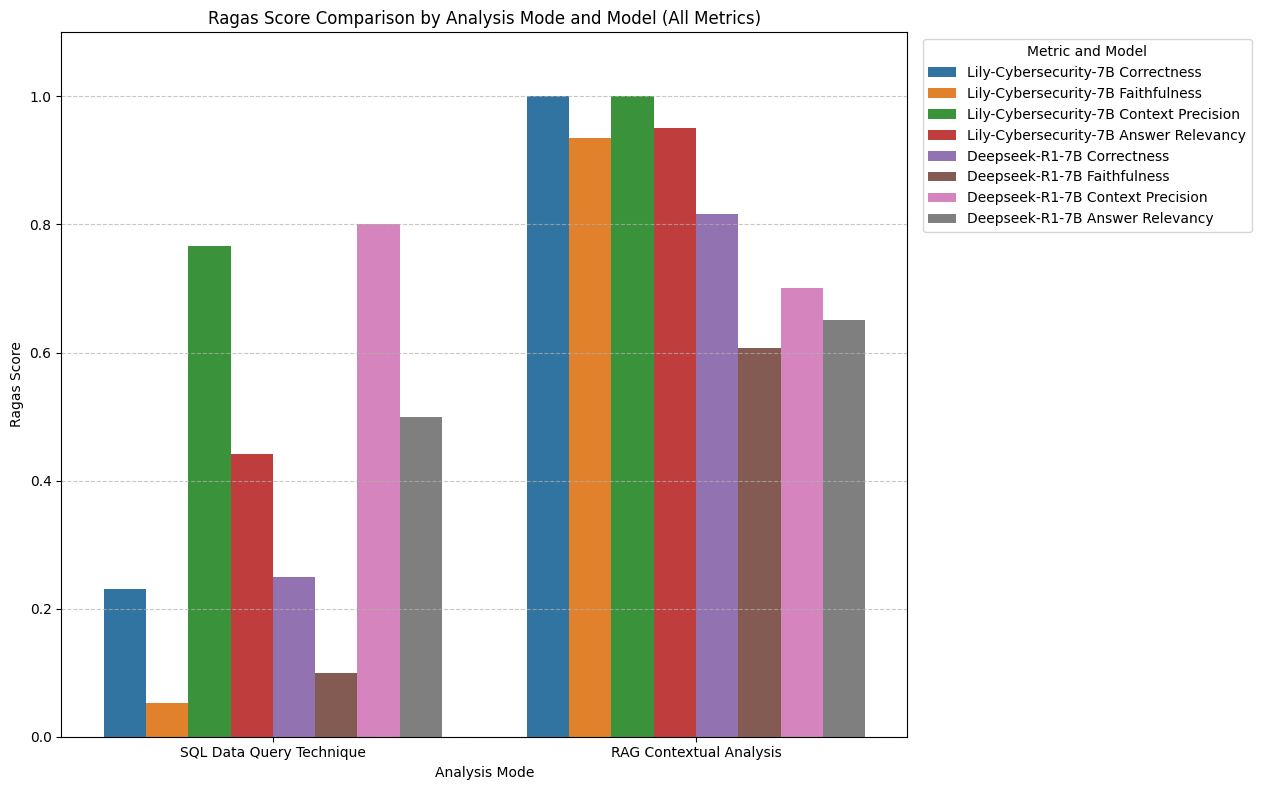

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Provided data as a list of lists (representing the rows)
# This structure needs to represent the COMPARISON data
# Update these placeholders with the actual scores from your Ragas evaluation
# Ensure all four metrics (faithfulness, context_precision, answer_relevancy, answer_correctness)
# are included in the dictionaries for both models and both analysis modes if available.
data = [
    ['SQL Data Query Technique',
     {'faithfulness': 0.0528, 'context_precision': 0.7667, 'answer_relevancy': 0.4411, 'answer_correctness': 0.2300}, # Lily-Cybersecurity-7B SQL scores
     {'faithfulness': 0.1000, 'context_precision': 0.8000, 'answer_relevancy': 0.5000, 'answer_correctness': 0.2500}  # Deepseek-R1-7B SQL scores (Placeholder - UPDATE THIS)
    ],
    ['RAG Contextual Analysis',
     {'faithfulness': 0.9346, 'context_precision': 1.0000, 'answer_relevancy': 0.9500, 'answer_correctness': 1.0000}, # Lily-Cybersecurity-7B RAG scores (Placeholder - UPDATE THIS)
     {'faithfulness': 0.6065, 'context_precision': 0.7000, 'answer_relevancy': 0.6500, 'answer_correctness': 0.8167}  # Deepseek-R1-7B RAG scores (Placeholder - UPDATE THIS)
    ]
]

# Create a DataFrame from the data
comparison_df = pd.DataFrame(data, columns=['Analysis Mode', 'Lily-Cybersecurity-7B Score', 'Deepseek-R1-7B Score'])

# Extract all four scores into separate columns for plotting
comparison_df['Lily-Cybersecurity-7B Correctness'] = comparison_df['Lily-Cybersecurity-7B Score'].apply(lambda x: x.get('answer_correctness', 0))
comparison_df['Lily-Cybersecurity-7B Faithfulness'] = comparison_df['Lily-Cybersecurity-7B Score'].apply(lambda x: x.get('faithfulness', 0))
comparison_df['Lily-Cybersecurity-7B Context Precision'] = comparison_df['Lily-Cybersecurity-7B Score'].apply(lambda x: x.get('context_precision', 0))
comparison_df['Lily-Cybersecurity-7B Answer Relevancy'] = comparison_df['Lily-Cybersecurity-7B Score'].apply(lambda x: x.get('answer_relevancy', 0))

comparison_df['Deepseek-R1-7B Correctness'] = comparison_df['Deepseek-R1-7B Score'].apply(lambda x: x.get('answer_correctness', 0))
comparison_df['Deepseek-R1-7B Faithfulness'] = comparison_df['Deepseek-R1-7B Score'].apply(lambda x: x.get('faithfulness', 0))
comparison_df['Deepseek-R1-7B Context Precision'] = comparison_df['Deepseek-R1-7B Score'].apply(lambda x: x.get('context_precision', 0))
comparison_df['Deepseek-R1-7B Answer Relevancy'] = comparison_df['Deepseek-R1-7B Score'].apply(lambda x: x.get('answer_relevancy', 0))


# Define the list of score columns to melt
score_columns_to_melt = [
    'Lily-Cybersecurity-7B Correctness', 'Lily-Cybersecurity-7B Faithfulness',
    'Lily-Cybersecurity-7B Context Precision', 'Lily-Cybersecurity-7B Answer Relevancy',
    'Deepseek-R1-7B Correctness', 'Deepseek-R1-7B Faithfulness',
    'Deepseek-R1-7B Context Precision', 'Deepseek-R1-7B Answer Relevancy'
]

# Melt the DataFrame for easier plotting with Seaborn
melted_df = comparison_df.melt(
    id_vars='Analysis Mode',
    value_vars=score_columns_to_melt,
    var_name='Metric and Model',
    value_name='Score'
)

# Add columns for Model and Metric
melted_df['Model'] = melted_df['Metric and Model'].apply(
    lambda x: 'Lily-Cybersecurity-7B' if 'Lily-Cybersecurity-7B' in x else 'Deepseek-R1-7B'
)
melted_df['Metric'] = melted_df['Metric and Model'].apply(
    lambda x: (
        'Answer Correctness' if 'Correctness' in x else
        'Faithfulness' if 'Faithfulness' in x else
        'Context Precision' if 'Context Precision' in x else
        'Answer Relevancy' if 'Answer Relevancy' in x else
        'Unknown Metric' # Handle unexpected cases
    )
)

# Plotting
plt.figure(figsize=(15, 8)) # Increased figure size to accommodate more bars
# Use a more contrasting palette like 'tab10'
sns.barplot(data=melted_df, x='Analysis Mode', y='Score', hue='Metric and Model', palette=sns.color_palette("tab10"))

plt.title('Ragas Score Comparison by Analysis Mode and Model (All Metrics)')
plt.ylabel('Ragas Score')
plt.ylim(0, 1.1) # Ragas scores are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0) # Keep labels horizontal

# Improve legend
# Position the legend strategically to avoid overlapping the plot
plt.legend(title='Metric and Model', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend

plt.show()

<div class="md-recitation">
  Sources
  <ol>
  <li><a href="https://github.com/llmware-ai/llmware/blob/main/examples/Use_Cases/biz_bot.py">SQL Data Query with LLM </a></li>
  <li><a href="https://www.techrxiv.org/users/683379/articles/678449-edge-iiotset-a-new-comprehensive-realistic-cyber-security-dataset-of-iot-and-iiot-applications-for-centralized-and-federated-learning">Edge-IIoTset: A New Comprehensive Realistic Cyber Security Dataset of IoT and IIoT Applications for Centralized and Federated Learning</a></li>
  <li><a href="https://arxiv.org/pdf/2309.15217">Ragas: Automated Evaluation of Retrieval Augmented Generation</a></li>
  <li><a href="https://www.kaggle.com/code/waleedgul/predict-attack-and-attack-type/input">Predict Attack and Attack Type</a></li>
  <li><a href="https://huggingface.co/segolilylabs/Lily-Cybersecurity-7B-v0.2">Segolily-Cybersecurity-7B-v0.2 </a></li>
  </ol>
</div>